In [1]:
# ============================================================
# RQ1 Reproducibility Builder
# Generates ONLY the numeric results used in the RQ1 section:
# - Base and Layer-2-observable counts
# - Table 2 medians
# - Pairwise MWU p-values and Cliff's delta values cited in
#   Obs. 1.1 to Obs. 1.5
#
# Revised Base definition:
#   Base_timing_regime == True
#   AND style in study styles
#   AND study_run_duration_seconds <= 86400
#   AND study_layer1_instrumentation_job_envelope_seconds != 0
#
# Reads from:
#   C:\Android Mobile App\ICST2026_Ext\MainDataset.csv
#
# Writes to:
#   C:\Android Mobile App\ICST2026_Ext\3.0-Observations\RQ1
#
# Outputs:
#   - rq1_counts.csv
#   - rq1_table2_medians.csv
#   - rq1_pairwise_statistics.csv
#   - rq1_numbers_bundle.xlsx
#   - rq1_run_notes.txt
#
# It also prints the generated numeric outputs to the console.
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
BASE_DIR = Path(r"C:\Android Mobile App\ICST2026_Ext")
IN_MAIN = BASE_DIR / "MainDataset.csv"
OUT_DIR = BASE_DIR / r"3.0-Observations\RQ1"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
STYLE_ORDER = ["Community", "GMD", "Third-Party", "Custom"]
MAX_REASONABLE_RUN_SECONDS = 24 * 60 * 60  # one full day


def to_num(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce")


def norm_bool(series: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False).astype(bool)

    s = series.astype(str).str.strip().str.lower()
    mapping = {
        "true": True,
        "false": False,
        "1": True,
        "0": False,
        "yes": True,
        "no": False,
        "y": True,
        "n": False,
        "base": True,
        "non-base": False,
    }
    return s.map(mapping).fillna(False).astype(bool)


def canon_style(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()
    mapping = {
        "community": "Community",
        "gmd": "GMD",
        "third-party": "Third-Party",
        "third party": "Third-Party",
        "custom": "Custom",
    }
    return mapping.get(s.lower(), s)


def cliff_delta(x: pd.Series, y: pd.Series) -> float:
    x = to_num(x).dropna().to_numpy()
    y = to_num(y).dropna().to_numpy()

    if len(x) == 0 or len(y) == 0:
        return np.nan

    u = mannwhitneyu(x, y, alternative="two-sided").statistic
    return float((2 * u) / (len(x) * len(y)) - 1)


def mwu_stats(df: pd.DataFrame, style_a: str, style_b: str, value_col: str) -> dict:
    x = to_num(df.loc[df["style"] == style_a, value_col]).dropna()
    y = to_num(df.loc[df["style"] == style_b, value_col]).dropna()

    if len(x) == 0 or len(y) == 0:
        return {
            "style_a": style_a,
            "style_b": style_b,
            "n_a": len(x),
            "n_b": len(y),
            "median_a": np.nan,
            "median_b": np.nan,
            "p_value": np.nan,
            "cliffs_delta": np.nan,
        }

    p = float(mannwhitneyu(x, y, alternative="two-sided").pvalue)
    d = cliff_delta(x, y)

    return {
        "style_a": style_a,
        "style_b": style_b,
        "n_a": len(x),
        "n_b": len(y),
        "median_a": float(x.median()),
        "median_b": float(y.median()),
        "p_value": p,
        "cliffs_delta": d,
    }


def save_csv(df: pd.DataFrame, path: Path):
    df.to_csv(path, index=False, encoding="utf-8-sig")


def print_section(title: str, df: pd.DataFrame):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)
    print(df.to_string(index=False))


# ------------------------------------------------------------
# Load
# ------------------------------------------------------------
if not IN_MAIN.exists():
    raise FileNotFoundError(f"MainDataset.csv not found: {IN_MAIN}")

df = pd.read_csv(IN_MAIN, low_memory=False)

required_cols = [
    "style",
    "Base_timing_regime",
    "Layer2_available_in_base",
    "study_run_duration_seconds",
    "study_layer1_time_to_instrumentation_envelope_seconds",
    "study_layer1_instrumentation_job_envelope_seconds",
    "study_layer1_post_instrumentation_tail_seconds",
    "study_pre_invocation_selected_stage3_seconds",
    "study_invocation_execution_window_selected_stage3_seconds",
    "study_post_invocation_selected_stage3_seconds",
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df["style"] = df["style"].map(canon_style)
df["Base_timing_regime"] = norm_bool(df["Base_timing_regime"])
df["Layer2_available_in_base"] = norm_bool(df["Layer2_available_in_base"])

measure_cols = {
    "run_duration": "study_run_duration_seconds",
    "time_to_instr": "study_layer1_time_to_instrumentation_envelope_seconds",
    "instr_job": "study_layer1_instrumentation_job_envelope_seconds",
    "post_instr": "study_layer1_post_instrumentation_tail_seconds",
    "pre_invoc": "study_pre_invocation_selected_stage3_seconds",
    "exec_window": "study_invocation_execution_window_selected_stage3_seconds",
    "post_invoc": "study_post_invocation_selected_stage3_seconds",
}

for col in measure_cols.values():
    df[col] = to_num(df[col])

# ------------------------------------------------------------
# Controlled subsets
# ------------------------------------------------------------
# Revised Base:
# - original Base_timing_regime
# - study style in scope
# - overall run duration <= one full day
# - Instrumentation Job duration is not zero
base_eligible_df = df.loc[
    df["Base_timing_regime"] & df["style"].isin(STYLE_ORDER)
].copy()

invalid_timing_record = (
    base_eligible_df["study_run_duration_seconds"].gt(MAX_REASONABLE_RUN_SECONDS)
    | base_eligible_df["study_layer1_instrumentation_job_envelope_seconds"].eq(0)
)

base_df = base_eligible_df.loc[~invalid_timing_record].copy()
l2_base_df = base_df.loc[base_df["Layer2_available_in_base"]].copy()

# ------------------------------------------------------------
# Counts used in RQ1 intro
# ------------------------------------------------------------
rq1_counts = pd.DataFrame([
    {"metric": "Base_n", "value": int(len(base_df))},
    {"metric": "Layer2_observable_Base_n", "value": int(len(l2_base_df))},
])

# ------------------------------------------------------------
# Table 2 medians
# ------------------------------------------------------------
table2_rows = []

for style in STYLE_ORDER:
    part = base_df.loc[base_df["style"] == style].copy()
    part_l2 = l2_base_df.loc[l2_base_df["style"] == style].copy()

    table2_rows.append({
        "Style": style,
        "Run dur.": part["study_run_duration_seconds"].median(),
        "Time to instr.": part["study_layer1_time_to_instrumentation_envelope_seconds"].median(),
        "Instr. Job": part["study_layer1_instrumentation_job_envelope_seconds"].median(),
        "Post-instr.": part["study_layer1_post_instrumentation_tail_seconds"].median(),
        "Pre-invoc.": part_l2["study_pre_invocation_selected_stage3_seconds"].median(),
        "Exec. window": part_l2["study_invocation_execution_window_selected_stage3_seconds"].median(),
        "Post-invoc.": part_l2["study_post_invocation_selected_stage3_seconds"].median(),
    })

rq1_table2 = pd.DataFrame(table2_rows)

# ------------------------------------------------------------
# Pairwise statistics cited in Obs. 1.1 to 1.5
# ------------------------------------------------------------
stats_rows = []

# Obs. 1.1: Community fastest completion-oriented profile
for b in ["GMD", "Third-Party", "Custom"]:
    r = mwu_stats(base_df, "Community", b, "study_run_duration_seconds")
    r["observation"] = "Obs. 1.1"
    r["comparison"] = f"Community vs. {b}"
    r["metric"] = "Run duration"
    stats_rows.append(r)

# Obs. 1.2: GMD reaches instrumentation path earliest
r = mwu_stats(base_df, "GMD", "Community", "study_layer1_time_to_instrumentation_envelope_seconds")
r["observation"] = "Obs. 1.2"
r["comparison"] = "GMD vs. Community"
r["metric"] = "Time to instr."
stats_rows.append(r)

r = mwu_stats(base_df, "GMD", "Custom", "study_layer1_time_to_instrumentation_envelope_seconds")
r["observation"] = "Obs. 1.2"
r["comparison"] = "GMD vs. Custom"
r["metric"] = "Time to instr."
stats_rows.append(r)

r = mwu_stats(l2_base_df, "GMD", "Third-Party", "study_pre_invocation_selected_stage3_seconds")
r["observation"] = "Obs. 1.2"
r["comparison"] = "GMD vs. Third-Party"
r["metric"] = "Pre-invoc."
stats_rows.append(r)

r = mwu_stats(l2_base_df, "GMD", "Community", "study_invocation_execution_window_selected_stage3_seconds")
r["observation"] = "Obs. 1.2"
r["comparison"] = "GMD vs. Community"
r["metric"] = "Exec. window"
stats_rows.append(r)

r = mwu_stats(base_df, "GMD", "Community", "study_run_duration_seconds")
r["observation"] = "Obs. 1.2"
r["comparison"] = "GMD vs. Community"
r["metric"] = "Run duration"
stats_rows.append(r)

# Obs. 1.3: Third-Party sustained-execution profile
r = mwu_stats(base_df, "Third-Party", "Community", "study_run_duration_seconds")
r["observation"] = "Obs. 1.3"
r["comparison"] = "Third-Party vs. Community"
r["metric"] = "Run duration"
stats_rows.append(r)

r = mwu_stats(l2_base_df, "Third-Party", "Community", "study_invocation_execution_window_selected_stage3_seconds")
r["observation"] = "Obs. 1.3"
r["comparison"] = "Third-Party vs. Community"
r["metric"] = "Exec. window"
stats_rows.append(r)

r = mwu_stats(l2_base_df, "Third-Party", "GMD", "study_pre_invocation_selected_stage3_seconds")
r["observation"] = "Obs. 1.3"
r["comparison"] = "Third-Party vs. GMD"
r["metric"] = "Pre-invoc."
stats_rows.append(r)

r = mwu_stats(base_df, "Third-Party", "Custom", "study_run_duration_seconds")
r["observation"] = "Obs. 1.3"
r["comparison"] = "Third-Party vs. Custom"
r["metric"] = "Run duration"
stats_rows.append(r)

r = mwu_stats(l2_base_df, "Third-Party", "Custom", "study_pre_invocation_selected_stage3_seconds")
r["observation"] = "Obs. 1.3"
r["comparison"] = "Third-Party vs. Custom"
r["metric"] = "Pre-invoc."
stats_rows.append(r)

r = mwu_stats(l2_base_df, "Third-Party", "Custom", "study_invocation_execution_window_selected_stage3_seconds")
r["observation"] = "Obs. 1.3"
r["comparison"] = "Third-Party vs. Custom"
r["metric"] = "Exec. window"
stats_rows.append(r)

# Obs. 1.4: Custom mixed timeliness case
r = mwu_stats(base_df, "Custom", "Community", "study_layer1_time_to_instrumentation_envelope_seconds")
r["observation"] = "Obs. 1.4"
r["comparison"] = "Custom vs. Community"
r["metric"] = "Time to instr."
stats_rows.append(r)

r = mwu_stats(base_df, "Custom", "Third-Party", "study_layer1_time_to_instrumentation_envelope_seconds")
r["observation"] = "Obs. 1.4"
r["comparison"] = "Custom vs. Third-Party"
r["metric"] = "Time to instr."
stats_rows.append(r)

r = mwu_stats(base_df, "Custom", "Community", "study_run_duration_seconds")
r["observation"] = "Obs. 1.4"
r["comparison"] = "Custom vs. Community"
r["metric"] = "Run duration"
stats_rows.append(r)

r = mwu_stats(base_df, "Custom", "GMD", "study_run_duration_seconds")
r["observation"] = "Obs. 1.4"
r["comparison"] = "Custom vs. GMD"
r["metric"] = "Run duration"
stats_rows.append(r)

r = mwu_stats(l2_base_df, "Custom", "GMD", "study_post_invocation_selected_stage3_seconds")
r["observation"] = "Obs. 1.4"
r["comparison"] = "Custom vs. GMD"
r["metric"] = "Post-invoc."
stats_rows.append(r)

r = mwu_stats(l2_base_df, "Custom", "Third-Party", "study_post_invocation_selected_stage3_seconds")
r["observation"] = "Obs. 1.4"
r["comparison"] = "Custom vs. Third-Party"
r["metric"] = "Post-invoc."
stats_rows.append(r)

# Obs. 1.5: Community speed advantage concentrated in main execution path
r = mwu_stats(base_df, "Community", "GMD", "study_layer1_post_instrumentation_tail_seconds")
r["observation"] = "Obs. 1.5"
r["comparison"] = "Community vs. GMD"
r["metric"] = "Post-instr."
stats_rows.append(r)

r = mwu_stats(base_df, "Community", "Third-Party", "study_layer1_post_instrumentation_tail_seconds")
r["observation"] = "Obs. 1.5"
r["comparison"] = "Community vs. Third-Party"
r["metric"] = "Post-instr."
stats_rows.append(r)

r = mwu_stats(base_df, "Community", "Custom", "study_layer1_post_instrumentation_tail_seconds")
r["observation"] = "Obs. 1.5"
r["comparison"] = "Community vs. Custom"
r["metric"] = "Post-instr."
stats_rows.append(r)

rq1_stats = pd.DataFrame(stats_rows)

rq1_stats = rq1_stats[
    [
        "observation",
        "comparison",
        "metric",
        "style_a",
        "style_b",
        "n_a",
        "n_b",
        "median_a",
        "median_b",
        "p_value",
        "cliffs_delta",
    ]
]

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
save_csv(rq1_counts, OUT_DIR / "rq1_counts.csv")
save_csv(rq1_table2, OUT_DIR / "rq1_table2_medians.csv")
save_csv(rq1_stats, OUT_DIR / "rq1_pairwise_statistics.csv")

xlsx_path = OUT_DIR / "rq1_numbers_bundle.xlsx"
with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    rq1_counts.to_excel(writer, sheet_name="counts", index=False)
    rq1_table2.to_excel(writer, sheet_name="table2_medians", index=False)
    rq1_stats.to_excel(writer, sheet_name="pairwise_stats", index=False)

notes = []
notes.append("RQ1 reproducibility outputs")
notes.append("=" * 60)
notes.append(f"Input: {IN_MAIN}")
notes.append(f"Output folder: {OUT_DIR}")
notes.append("")
notes.append("Resolved regimes:")
notes.append(
    "- Base subset: Base_timing_regime == True, "
    "style in study styles, run duration <= 86400 seconds, "
    "and Instrumentation Job duration != 0"
)
notes.append(
    "- Layer 2 subset: revised Base subset AND Layer2_available_in_base == True"
)
notes.append("")
notes.append("Generated files:")
notes.append("- rq1_counts.csv")
notes.append("- rq1_table2_medians.csv")
notes.append("- rq1_pairwise_statistics.csv")
notes.append("- rq1_numbers_bundle.xlsx")

(OUT_DIR / "rq1_run_notes.txt").write_text("\n".join(notes), encoding="utf-8")

# ------------------------------------------------------------
# Print
# ------------------------------------------------------------
print_section("RQ1 COUNTS", rq1_counts)
print_section("RQ1 TABLE 2 MEDIANS", rq1_table2)
print_section("RQ1 PAIRWISE STATISTICS", rq1_stats)

print("\nSaved outputs to:")
print(OUT_DIR)


RQ1 COUNTS
                  metric  value
                  Base_n   7330
Layer2_observable_Base_n   5057

RQ1 TABLE 2 MEDIANS
      Style  Run dur.  Time to instr.  Instr. Job  Post-instr.  Pre-invoc.  Exec. window  Post-invoc.
  Community     884.0             4.0       660.0          2.0       187.0         397.0         75.0
        GMD    1212.0             3.0      1208.0          1.0        79.5        1076.0          4.0
Third-Party    1783.5             4.0      1760.5          1.0       561.0        1881.5          5.0
     Custom    1817.0             3.0      1609.5          1.0       131.5         726.0        942.5

RQ1 PAIRWISE STATISTICS
observation                comparison         metric     style_a     style_b  n_a  n_b  median_a  median_b      p_value  cliffs_delta
   Obs. 1.1         Community vs. GMD   Run duration   Community         GMD 6565  263     884.0    1212.0 7.474537e-12     -0.248659
   Obs. 1.1 Community vs. Third-Party   Run duration   Community Thi

In [ ]:
##RQ2

In [2]:
# ============================================================
# RQ2 Reproducibility Builder
# Generates ONLY the numeric results used in the RQ2 section:
# - Base and Layer-2-observable counts
# - Table 3 consistency / predictability values
# - Pairwise MWU p-values and Cliff's delta values cited in
#   Obs. 2.1 to Obs. 2.4
#
# Revised Base definition:
#   Base_timing_regime == True
#   AND style in study styles
#   AND study_run_duration_seconds <= 86400
#   AND study_layer1_instrumentation_job_envelope_seconds != 0
#
# Reads from:
#   C:\Android Mobile App\ICST2026_Ext\MainDataset.csv
#
# Writes to:
#   C:\Android Mobile App\ICST2026_Ext\3.0-Observations\RQ2
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

BASE_DIR = Path(r"C:\Android Mobile App\ICST2026_Ext")
IN_MAIN = BASE_DIR / "MainDataset.csv"
OUT_DIR = BASE_DIR / r"3.0-Observations\RQ2"
OUT_DIR.mkdir(parents=True, exist_ok=True)

STYLE_ORDER = ["Community", "GMD", "Third-Party", "Custom"]
MAX_REASONABLE_RUN_SECONDS = 24 * 60 * 60  # one full day


def to_num(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce")


def norm_bool(series: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False).astype(bool)

    s = series.astype(str).str.strip().str.lower()
    mapping = {
        "true": True, "false": False,
        "1": True, "0": False,
        "yes": True, "no": False,
        "y": True, "n": False,
        "base": True, "non-base": False,
    }
    return s.map(mapping).fillna(False).astype(bool)


def canon_style(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()
    mapping = {
        "community": "Community",
        "gmd": "GMD",
        "third-party": "Third-Party",
        "third party": "Third-Party",
        "custom": "Custom",
    }
    return mapping.get(s.lower(), s)


def cliff_delta(x: pd.Series, y: pd.Series) -> float:
    x = to_num(x).dropna().to_numpy()
    y = to_num(y).dropna().to_numpy()

    if len(x) == 0 or len(y) == 0:
        return np.nan

    u = mannwhitneyu(x, y, alternative="two-sided").statistic
    return float((2 * u) / (len(x) * len(y)) - 1)


def mwu_stats(df: pd.DataFrame, style_a: str, style_b: str, value_col: str) -> dict:
    x = to_num(df.loc[df["style"] == style_a, value_col]).dropna()
    y = to_num(df.loc[df["style"] == style_b, value_col]).dropna()

    if len(x) == 0 or len(y) == 0:
        return {
            "style_a": style_a,
            "style_b": style_b,
            "n_a": len(x),
            "n_b": len(y),
            "median_a": np.nan,
            "median_b": np.nan,
            "p_value": np.nan,
            "cliffs_delta": np.nan,
        }

    p = float(mannwhitneyu(x, y, alternative="two-sided").pvalue)
    d = cliff_delta(x, y)

    return {
        "style_a": style_a,
        "style_b": style_b,
        "n_a": len(x),
        "n_b": len(y),
        "median_a": float(x.median()),
        "median_b": float(y.median()),
        "p_value": p,
        "cliffs_delta": d,
    }


def save_csv(df: pd.DataFrame, path: Path):
    df.to_csv(path, index=False, encoding="utf-8-sig")


def print_section(title: str, df: pd.DataFrame):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)
    print(df.to_string(index=False))


def add_norm_abs_dev(df_part: pd.DataFrame, measure_col: str, out_col: str) -> pd.DataFrame:
    out = df_part.copy()

    med_by_style = (
        out.groupby("style")[measure_col]
        .median()
        .rename("_style_median")
        .reset_index()
    )

    out = out.merge(med_by_style, on="style", how="left")
    out[out_col] = (
        (to_num(out[measure_col]) - to_num(out["_style_median"])).abs()
        / to_num(out["_style_median"])
    )
    out = out.drop(columns=["_style_median"])

    return out


if not IN_MAIN.exists():
    raise FileNotFoundError(f"MainDataset.csv not found: {IN_MAIN}")

df = pd.read_csv(IN_MAIN, low_memory=False)

required_cols = [
    "style",
    "Base_timing_regime",
    "Layer2_available_in_base",
    "study_run_duration_seconds",
    "study_layer1_instrumentation_job_envelope_seconds",
    "study_pre_invocation_selected_stage3_seconds",
    "study_invocation_execution_window_selected_stage3_seconds",
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df["style"] = df["style"].map(canon_style)
df["Base_timing_regime"] = norm_bool(df["Base_timing_regime"])
df["Layer2_available_in_base"] = norm_bool(df["Layer2_available_in_base"])

for col in [
    "study_run_duration_seconds",
    "study_layer1_instrumentation_job_envelope_seconds",
    "study_pre_invocation_selected_stage3_seconds",
    "study_invocation_execution_window_selected_stage3_seconds",
]:
    df[col] = to_num(df[col])

# ------------------------------------------------------------
# Controlled subsets
# ------------------------------------------------------------
base_eligible_df = df.loc[
    df["Base_timing_regime"] & df["style"].isin(STYLE_ORDER)
].copy()

invalid_timing_record = (
    base_eligible_df["study_run_duration_seconds"].gt(MAX_REASONABLE_RUN_SECONDS)
    | base_eligible_df["study_layer1_instrumentation_job_envelope_seconds"].eq(0)
)

base_df = base_eligible_df.loc[~invalid_timing_record].copy()
l2_base_df = base_df.loc[base_df["Layer2_available_in_base"]].copy()

# ------------------------------------------------------------
# Derived predictability measures
# ------------------------------------------------------------
base_df = add_norm_abs_dev(
    base_df,
    "study_run_duration_seconds",
    "nad_run_duration",
)

base_df = add_norm_abs_dev(
    base_df,
    "study_layer1_instrumentation_job_envelope_seconds",
    "nad_instr_job",
)

l2_base_df = add_norm_abs_dev(
    l2_base_df,
    "study_invocation_execution_window_selected_stage3_seconds",
    "nad_exec_window",
)

l2_base_df = add_norm_abs_dev(
    l2_base_df,
    "study_pre_invocation_selected_stage3_seconds",
    "nad_pre_invocation",
)

rq2_counts = pd.DataFrame([
    {"metric": "Base_n", "value": int(len(base_df))},
    {"metric": "Layer2_observable_Base_n", "value": int(len(l2_base_df))},
])

# ------------------------------------------------------------
# Table 3 consistency / predictability profile
# ------------------------------------------------------------
rows = []

for style in STYLE_ORDER:
    part = base_df.loc[base_df["style"] == style].copy()
    part_l2 = l2_base_df.loc[l2_base_df["style"] == style].copy()

    run_median = float(part["study_run_duration_seconds"].median()) if len(part) else np.nan
    p95_run = float(part["study_run_duration_seconds"].quantile(0.95)) if len(part) else np.nan

    rows.append({
        "Style": style,
        "Norm. abs. dev. (run dur.)": float(part["nad_run_duration"].median()) if len(part) else np.nan,
        "Norm. abs. dev. (Instr. Job)": float(part["nad_instr_job"].median()) if len(part) else np.nan,
        "Norm. abs. dev. (L2 exec. window)": float(part_l2["nad_exec_window"].median()) if len(part_l2) else np.nan,
        "Norm. abs. dev. (L2 pre-invoc.)": float(part_l2["nad_pre_invocation"].median()) if len(part_l2) else np.nan,
        "P95 run dur. (s)": p95_run,
        "P95 / median (run dur.)": (
            p95_run / run_median
            if pd.notna(p95_run) and pd.notna(run_median) and run_median != 0
            else np.nan
        ),
        "Median run dur. (s)": run_median,
        "Median Instr. Job (s)": (
            float(part["study_layer1_instrumentation_job_envelope_seconds"].median())
            if len(part)
            else np.nan
        ),
        "Median L2 exec. window (s)": (
            float(part_l2["study_invocation_execution_window_selected_stage3_seconds"].median())
            if len(part_l2)
            else np.nan
        ),
    })

rq2_table3 = pd.DataFrame(rows)

# ------------------------------------------------------------
# Pairwise statistics cited in Obs. 2.1 to 2.4
# ------------------------------------------------------------
stats_rows = []

for b in ["Community", "Custom", "Third-Party"]:
    r = mwu_stats(base_df, "GMD", b, "nad_run_duration")
    r["observation"] = "Obs. 2.1"
    r["comparison"] = f"GMD vs. {b}"
    r["metric"] = "Norm. abs. dev. (run dur.)"
    stats_rows.append(r)

r = mwu_stats(base_df, "Community", "GMD", "nad_run_duration")
r["observation"] = "Obs. 2.2"
r["comparison"] = "Community vs. GMD"
r["metric"] = "Norm. abs. dev. (run dur.)"
stats_rows.append(r)

r = mwu_stats(base_df, "Community", "Custom", "nad_run_duration")
r["observation"] = "Obs. 2.2"
r["comparison"] = "Community vs. Custom"
r["metric"] = "Norm. abs. dev. (run dur.)"
stats_rows.append(r)

r = mwu_stats(base_df, "Community", "Custom", "nad_instr_job")
r["observation"] = "Obs. 2.2"
r["comparison"] = "Community vs. Custom"
r["metric"] = "Norm. abs. dev. (Instr. Job)"
stats_rows.append(r)

r = mwu_stats(base_df, "Third-Party", "GMD", "nad_run_duration")
r["observation"] = "Obs. 2.3"
r["comparison"] = "Third-Party vs. GMD"
r["metric"] = "Norm. abs. dev. (run dur.)"
stats_rows.append(r)

r = mwu_stats(base_df, "Third-Party", "GMD", "nad_instr_job")
r["observation"] = "Obs. 2.3"
r["comparison"] = "Third-Party vs. GMD"
r["metric"] = "Norm. abs. dev. (Instr. Job)"
stats_rows.append(r)

r = mwu_stats(l2_base_df, "Third-Party", "GMD", "nad_exec_window")
r["observation"] = "Obs. 2.3"
r["comparison"] = "Third-Party vs. GMD"
r["metric"] = "Norm. abs. dev. (L2 exec. window)"
stats_rows.append(r)

r = mwu_stats(base_df, "Custom", "Community", "nad_run_duration")
r["observation"] = "Obs. 2.4"
r["comparison"] = "Custom vs. Community"
r["metric"] = "Norm. abs. dev. (run dur.)"
stats_rows.append(r)

r = mwu_stats(base_df, "Custom", "Community", "nad_instr_job")
r["observation"] = "Obs. 2.4"
r["comparison"] = "Custom vs. Community"
r["metric"] = "Norm. abs. dev. (Instr. Job)"
stats_rows.append(r)

rq2_stats = pd.DataFrame(stats_rows)

rq2_stats = rq2_stats[
    [
        "observation",
        "comparison",
        "metric",
        "style_a",
        "style_b",
        "n_a",
        "n_b",
        "median_a",
        "median_b",
        "p_value",
        "cliffs_delta",
    ]
]

save_csv(rq2_counts, OUT_DIR / "rq2_counts.csv")
save_csv(rq2_table3, OUT_DIR / "rq2_table3_predictability_profile.csv")
save_csv(rq2_stats, OUT_DIR / "rq2_pairwise_statistics.csv")

xlsx_path = OUT_DIR / "rq2_numbers_bundle.xlsx"
with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    rq2_counts.to_excel(writer, sheet_name="counts", index=False)
    rq2_table3.to_excel(writer, sheet_name="table3_profile", index=False)
    rq2_stats.to_excel(writer, sheet_name="pairwise_stats", index=False)

notes = []
notes.append("RQ2 reproducibility outputs")
notes.append("=" * 60)
notes.append(f"Input: {IN_MAIN}")
notes.append(f"Output folder: {OUT_DIR}")
notes.append("")
notes.append("Resolved regimes:")
notes.append(
    "- Base subset: Base_timing_regime == True, "
    "style in study styles, run duration <= 86400 seconds, "
    "and Instrumentation Job duration != 0"
)
notes.append(
    "- Layer 2 subset: revised Base subset AND Layer2_available_in_base == True"
)
notes.append("")
notes.append("Derived measures:")
notes.append("- Normalized absolute deviation = |x - style_median| / style_median")
notes.append("- P95 run duration = 95th percentile within style under revised Base")
notes.append("- P95/median = P95 run duration / style median run duration")
notes.append("")
notes.append("Generated files:")
notes.append("- rq2_counts.csv")
notes.append("- rq2_table3_predictability_profile.csv")
notes.append("- rq2_pairwise_statistics.csv")
notes.append("- rq2_numbers_bundle.xlsx")

(OUT_DIR / "rq2_run_notes.txt").write_text("\n".join(notes), encoding="utf-8")

print_section("RQ2 COUNTS", rq2_counts)
print_section("RQ2 TABLE 3 PREDICTABILITY PROFILE", rq2_table3)
print_section("RQ2 PAIRWISE STATISTICS", rq2_stats)

print("\nSaved outputs to:")
print(OUT_DIR)


RQ2 COUNTS
                  metric  value
                  Base_n   7330
Layer2_observable_Base_n   5057

RQ2 TABLE 3 PREDICTABILITY PROFILE
      Style  Norm. abs. dev. (run dur.)  Norm. abs. dev. (Instr. Job)  Norm. abs. dev. (L2 exec. window)  Norm. abs. dev. (L2 pre-invoc.)  P95 run dur. (s)  P95 / median (run dur.)  Median run dur. (s)  Median Instr. Job (s)  Median L2 exec. window (s)
  Community                    0.502262                      0.503030                           0.513854                         0.914439           11302.2                12.785294                884.0                  660.0                       397.0
        GMD                    0.061056                      0.059603                           0.044610                         0.106918            1483.4                 1.223927               1212.0                 1208.0                      1076.0
Third-Party                    0.219232                      0.216416                           0

In [ ]:
#RQ3

In [3]:
# ============================================================
# RQ3 Reproducibility Builder
# Generates numeric results used in the RQ3 section:
# - Base count under the revised Base definition
# - Layer-2-included Base count under the revised Base definition
# - RQ3 overhead-placement table with coverage:
#     runs, repositories, repo-workflows, and Level 2 share medians
# - Pairwise MWU p-values and Cliff's delta values cited in
#   Obs. 3.1 to Obs. 3.4
#
# Revised Base definition:
#   Base_timing_regime == True
#   AND style in study styles
#   AND study_run_duration_seconds <= 86400
#   AND study_layer1_instrumentation_job_envelope_seconds != 0
#
# Reads from:
#   C:\Android Mobile App\ICST2026_Ext\MainDataset.csv
#
# Writes to:
#   C:\Android Mobile App\ICST2026_Ext\3.0-Observations\RQ3
#
# Outputs:
#   - rq3_counts.csv
#   - rq3_table_overhead_coverage_raw.csv
#   - rq3_table_overhead_coverage_percent.csv
#   - rq3_table_overhead_coverage_percent_rounded.csv
#   - rq3_pairwise_statistics_raw.csv
#   - rq3_pairwise_statistics_percent.csv
#   - rq3_numbers_bundle.xlsx
#   - rq3_run_notes.txt
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
BASE_DIR = Path(r"C:\Android Mobile App\ICST2026_Ext")
IN_MAIN = BASE_DIR / "MainDataset.csv"
OUT_DIR = BASE_DIR / r"3.0-Observations\RQ3"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
STYLE_ORDER = ["Community", "GMD", "Third-Party", "Custom"]
MAX_REASONABLE_RUN_SECONDS = 24 * 60 * 60  # one full day


def to_num(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce")


def norm_bool(series: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False).astype(bool)

    s = series.astype(str).str.strip().str.lower()
    mapping = {
        "true": True,
        "false": False,
        "1": True,
        "0": False,
        "yes": True,
        "no": False,
        "y": True,
        "n": False,
        "base": True,
        "non-base": False,
    }
    return s.map(mapping).fillna(False).astype(bool)


def canon_style(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()
    mapping = {
        "community": "Community",
        "gmd": "GMD",
        "third-party": "Third-Party",
        "third party": "Third-Party",
        "custom": "Custom",
    }
    return mapping.get(s.lower(), s)


def first_existing_col(df: pd.DataFrame, candidates: list[str]) -> str | None:
    for col in candidates:
        if col in df.columns:
            return col
    return None


def make_repo_workflow_key(df: pd.DataFrame, repo_col: str, workflow_col: str) -> pd.Series:
    return (
        df[repo_col].astype(str).str.strip()
        + "::"
        + df[workflow_col].astype(str).str.strip()
    )


def cliff_delta(x: pd.Series, y: pd.Series) -> float:
    x = to_num(x).dropna().to_numpy()
    y = to_num(y).dropna().to_numpy()

    if len(x) == 0 or len(y) == 0:
        return np.nan

    u = mannwhitneyu(x, y, alternative="two-sided").statistic
    return float((2 * u) / (len(x) * len(y)) - 1)


def mwu_stats(df: pd.DataFrame, style_a: str, style_b: str, value_col: str) -> dict:
    x = to_num(df.loc[df["style"] == style_a, value_col]).dropna()
    y = to_num(df.loc[df["style"] == style_b, value_col]).dropna()

    if len(x) == 0 or len(y) == 0:
        return {
            "style_a": style_a,
            "style_b": style_b,
            "n_a": len(x),
            "n_b": len(y),
            "median_a": np.nan,
            "median_b": np.nan,
            "p_value": np.nan,
            "cliffs_delta": np.nan,
        }

    p = float(mannwhitneyu(x, y, alternative="two-sided").pvalue)
    d = cliff_delta(x, y)

    return {
        "style_a": style_a,
        "style_b": style_b,
        "n_a": len(x),
        "n_b": len(y),
        "median_a": float(x.median()),
        "median_b": float(y.median()),
        "p_value": p,
        "cliffs_delta": d,
    }


def save_csv(df: pd.DataFrame, path: Path):
    df.to_csv(path, index=False, encoding="utf-8-sig")


def print_section(title: str, df: pd.DataFrame):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)
    print(df.to_string(index=False))


# ------------------------------------------------------------
# Load
# ------------------------------------------------------------
if not IN_MAIN.exists():
    raise FileNotFoundError(f"MainDataset.csv not found: {IN_MAIN}")

df = pd.read_csv(IN_MAIN, low_memory=False)

# ------------------------------------------------------------
# Resolve required / coverage columns
# ------------------------------------------------------------
required_cols = [
    "style",
    "Base_timing_regime",
    "Layer2_available_in_base",
    "study_run_duration_seconds",
    "study_layer1_instrumentation_job_envelope_seconds",
    "study_pre_invocation_selected_stage3_seconds",
    "study_invocation_execution_window_selected_stage3_seconds",
    "study_post_invocation_selected_stage3_seconds",
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

repo_col = first_existing_col(
    df,
    [
        "full_name",
        "repo_full_name",
        "repository_full_name",
        "repository",
        "repo",
    ],
)

workflow_col = first_existing_col(
    df,
    [
        "workflow_id",
        "workflow_database_id",
        "workflow_node_id",
        "workflow_name",
        "workflow_path",
        "workflow_file",
    ],
)

if repo_col is None:
    raise ValueError(
        "Could not find a repository column. Expected one of: "
        "full_name, repo_full_name, repository_full_name, repository, repo"
    )

if workflow_col is None:
    raise ValueError(
        "Could not find a workflow column. Expected one of: "
        "workflow_id, workflow_database_id, workflow_node_id, "
        "workflow_name, workflow_path, workflow_file"
    )

print(f"Using repository column: {repo_col}")
print(f"Using workflow column: {workflow_col}")

# ------------------------------------------------------------
# Normalize fields
# ------------------------------------------------------------
df["style"] = df["style"].map(canon_style)
df["Base_timing_regime"] = norm_bool(df["Base_timing_regime"])
df["Layer2_available_in_base"] = norm_bool(df["Layer2_available_in_base"])

for col in [
    "study_run_duration_seconds",
    "study_layer1_instrumentation_job_envelope_seconds",
    "study_pre_invocation_selected_stage3_seconds",
    "study_invocation_execution_window_selected_stage3_seconds",
    "study_post_invocation_selected_stage3_seconds",
]:
    df[col] = to_num(df[col])

df["repo_workflow_key"] = make_repo_workflow_key(df, repo_col, workflow_col)

# ------------------------------------------------------------
# Controlled subsets
# ------------------------------------------------------------
# Revised Base:
# - original Base_timing_regime
# - study style in scope
# - overall run duration <= one full day
# - Instrumentation Job duration is not zero
base_eligible_df = df.loc[
    df["Base_timing_regime"] & df["style"].isin(STYLE_ORDER)
].copy()

invalid_timing_record = (
    base_eligible_df["study_run_duration_seconds"].gt(MAX_REASONABLE_RUN_SECONDS)
    | base_eligible_df["study_layer1_instrumentation_job_envelope_seconds"].eq(0)
)

base_df = base_eligible_df.loc[~invalid_timing_record].copy()

l2_base_df = base_df.loc[
    base_df["Layer2_available_in_base"]
].copy()

# ------------------------------------------------------------
# Derived share measures
# ------------------------------------------------------------
den = l2_base_df["study_run_duration_seconds"].replace(0, np.nan)

l2_base_df["share_pre"] = (
    l2_base_df["study_pre_invocation_selected_stage3_seconds"] / den
)

l2_base_df["share_exec"] = (
    l2_base_df["study_invocation_execution_window_selected_stage3_seconds"] / den
)

l2_base_df["share_post"] = (
    l2_base_df["study_post_invocation_selected_stage3_seconds"] / den
)

# ------------------------------------------------------------
# Counts used in RQ3 intro
# ------------------------------------------------------------
rq3_counts = pd.DataFrame([
    {"metric": "Base_n", "value": int(len(base_df))},
    {"metric": "Layer2_included_Base_n", "value": int(len(l2_base_df))},
])

# ------------------------------------------------------------
# RQ3 overhead-placement table with coverage
# ------------------------------------------------------------
table_rows = []

for style in STYLE_ORDER:
    part = l2_base_df.loc[l2_base_df["style"] == style].copy()

    table_rows.append({
        "Style": style,
        "Runs": int(len(part)),
        "Repositories": int(part[repo_col].nunique(dropna=True)),
        "Workflows": int(part["repo_workflow_key"].nunique(dropna=True)),
        "Pre share median": float(part["share_pre"].median()) if len(part) else np.nan,
        "Exec share median": float(part["share_exec"].median()) if len(part) else np.nan,
        "Post share median": float(part["share_post"].median()) if len(part) else np.nan,
    })

rq3_table = pd.DataFrame(table_rows)

rq3_table_percent = rq3_table.copy()
for c in ["Pre share median", "Exec share median", "Post share median"]:
    rq3_table_percent[c] = rq3_table_percent[c] * 100

rq3_table_percent_rounded = rq3_table_percent.copy()
for c in ["Pre share median", "Exec share median", "Post share median"]:
    rq3_table_percent_rounded[c] = rq3_table_percent_rounded[c].round(1)

# ------------------------------------------------------------
# Pairwise statistics cited in Obs. 3.1 to Obs. 3.4
# ------------------------------------------------------------
stats_rows = []

for style_a, style_b, metric_col, metric_name in [
    ("GMD", "Community", "share_exec", "L2 execution share"),
    ("GMD", "Third-Party", "share_exec", "L2 execution share"),
    ("GMD", "Community", "share_post", "L2 post-invocation share"),
    ("GMD", "Custom", "share_post", "L2 post-invocation share"),
]:
    r = mwu_stats(l2_base_df, style_a, style_b, metric_col)
    r["observation"] = "Obs. 3.1"
    r["comparison"] = f"{style_a} vs. {style_b}"
    r["metric"] = metric_name
    stats_rows.append(r)

for style_a, style_b, metric_col, metric_name in [
    ("Third-Party", "GMD", "share_pre", "L2 pre-invocation share"),
    ("Third-Party", "Community", "share_exec", "L2 execution share"),
    ("Third-Party", "Community", "share_post", "L2 post-invocation share"),
]:
    r = mwu_stats(l2_base_df, style_a, style_b, metric_col)
    r["observation"] = "Obs. 3.2"
    r["comparison"] = f"{style_a} vs. {style_b}"
    r["metric"] = metric_name
    stats_rows.append(r)

for style_a, style_b, metric_col, metric_name in [
    ("Community", "GMD", "share_exec", "L2 execution share"),
    ("Community", "Third-Party", "share_exec", "L2 execution share"),
    ("Community", "Third-Party", "share_post", "L2 post-invocation share"),
    ("Community", "Third-Party", "share_pre", "L2 pre-invocation share"),
]:
    r = mwu_stats(l2_base_df, style_a, style_b, metric_col)
    r["observation"] = "Obs. 3.3"
    r["comparison"] = f"{style_a} vs. {style_b}"
    r["metric"] = metric_name
    stats_rows.append(r)

for style_a, style_b, metric_col, metric_name in [
    ("Custom", "GMD", "share_post", "L2 post-invocation share"),
    ("Custom", "Third-Party", "share_post", "L2 post-invocation share"),
    ("Custom", "GMD", "share_exec", "L2 execution share"),
    ("Custom", "Third-Party", "share_exec", "L2 execution share"),
]:
    r = mwu_stats(l2_base_df, style_a, style_b, metric_col)
    r["observation"] = "Obs. 3.4"
    r["comparison"] = f"{style_a} vs. {style_b}"
    r["metric"] = metric_name
    stats_rows.append(r)

rq3_stats = pd.DataFrame(stats_rows)
rq3_stats = rq3_stats[
    [
        "observation",
        "comparison",
        "metric",
        "style_a",
        "style_b",
        "n_a",
        "n_b",
        "median_a",
        "median_b",
        "p_value",
        "cliffs_delta",
    ]
]

rq3_stats_percent = rq3_stats.copy()
for c in ["median_a", "median_b"]:
    rq3_stats_percent[c] = rq3_stats_percent[c] * 100

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
save_csv(rq3_counts, OUT_DIR / "rq3_counts.csv")
save_csv(rq3_table, OUT_DIR / "rq3_table_overhead_coverage_raw.csv")
save_csv(rq3_table_percent, OUT_DIR / "rq3_table_overhead_coverage_percent.csv")
save_csv(rq3_table_percent_rounded, OUT_DIR / "rq3_table_overhead_coverage_percent_rounded.csv")
save_csv(rq3_stats, OUT_DIR / "rq3_pairwise_statistics_raw.csv")
save_csv(rq3_stats_percent, OUT_DIR / "rq3_pairwise_statistics_percent.csv")

xlsx_path = OUT_DIR / "rq3_numbers_bundle.xlsx"
with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    rq3_counts.to_excel(writer, sheet_name="counts", index=False)
    rq3_table.to_excel(writer, sheet_name="overhead_table_raw", index=False)
    rq3_table_percent.to_excel(writer, sheet_name="overhead_table_percent", index=False)
    rq3_table_percent_rounded.to_excel(writer, sheet_name="overhead_table_rounded", index=False)
    rq3_stats.to_excel(writer, sheet_name="pairwise_raw", index=False)
    rq3_stats_percent.to_excel(writer, sheet_name="pairwise_percent", index=False)

notes = []
notes.append("RQ3 reproducibility outputs")
notes.append("=" * 60)
notes.append(f"Input: {IN_MAIN}")
notes.append(f"Output folder: {OUT_DIR}")
notes.append("")
notes.append("Resolved regimes:")
notes.append(
    "- Base subset: Base_timing_regime == True, "
    "style in study styles, run duration <= 86400 seconds, "
    "and Instrumentation Job duration != 0"
)
notes.append(
    "- Layer 2 subset: revised Base subset AND Layer2_available_in_base == True"
)
notes.append("")
notes.append("Coverage fields:")
notes.append(f"- Repository column used: {repo_col}")
notes.append(f"- Workflow column used: {workflow_col}")
notes.append("- Workflows are counted as distinct repository--workflow combinations.")
notes.append("")
notes.append("Derived measures:")
notes.append("- share_pre  = study_pre_invocation_selected_stage3_seconds / study_run_duration_seconds")
notes.append("- share_exec = study_invocation_execution_window_selected_stage3_seconds / study_run_duration_seconds")
notes.append("- share_post = study_post_invocation_selected_stage3_seconds / study_run_duration_seconds")
notes.append("")
notes.append("Files:")
notes.append("- rq3_counts.csv")
notes.append("- rq3_table_overhead_coverage_raw.csv")
notes.append("- rq3_table_overhead_coverage_percent.csv")
notes.append("- rq3_table_overhead_coverage_percent_rounded.csv")
notes.append("- rq3_pairwise_statistics_raw.csv")
notes.append("- rq3_pairwise_statistics_percent.csv")
notes.append("- rq3_numbers_bundle.xlsx")

(OUT_DIR / "rq3_run_notes.txt").write_text("\n".join(notes), encoding="utf-8")

print_section("RQ3 COUNTS", rq3_counts)
print_section("RQ3 OVERHEAD TABLE WITH COVERAGE - RAW FRACTIONS", rq3_table)
print_section("RQ3 OVERHEAD TABLE WITH COVERAGE - PERCENT", rq3_table_percent)
print_section("RQ3 OVERHEAD TABLE WITH COVERAGE - PERCENT ROUNDED", rq3_table_percent_rounded)
print_section("RQ3 PAIRWISE STATISTICS - RAW FRACTIONS", rq3_stats)
print_section("RQ3 PAIRWISE STATISTICS - PERCENT MEDIANS", rq3_stats_percent)

print("\nSaved outputs to:")
print(OUT_DIR)

Using repository column: full_name
Using workflow column: workflow_id

RQ3 COUNTS
                metric  value
                Base_n   7330
Layer2_included_Base_n   5057

RQ3 OVERHEAD TABLE WITH COVERAGE - RAW FRACTIONS
      Style  Runs  Repositories  Workflows  Pre share median  Exec share median  Post share median
  Community  4779            59         65          0.167614           0.393162           0.077143
        GMD   134             3          3          0.068030           0.926966           0.003970
Third-Party   114             7         21          0.232757           0.700653           0.002528
     Custom    30             2          3          0.074360           0.359364           0.564484

RQ3 OVERHEAD TABLE WITH COVERAGE - PERCENT
      Style  Runs  Repositories  Workflows  Pre share median  Exec share median  Post share median
  Community  4779            59         65         16.761364          39.316239           7.714286
        GMD   134             3          

In [ ]:
#RQ 4

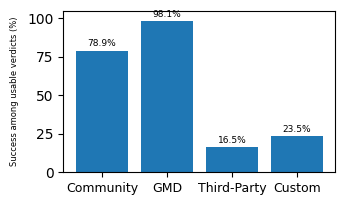

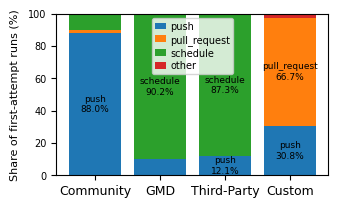


RQ4 COUNTS
                                                         metric  value
                       First_attempt_instrumentation_executed_n   8603
                                        Usable_verdict_subset_n   7744
        Diagnostic_run_duration_gt_1day_n_not_excluded_from_RQ4    199
           Diagnostic_instr_job_eq_zero_n_not_excluded_from_RQ4    267
Diagnostic_base_timing_quality_excluded_n_not_excluded_from_RQ4    445

RQ4 COMPACT PROFILE
      Style    Usable   Success              Trigger
  Community 89.142195 78.948129         push (88.0%)
        GMD 99.245283 98.098859     schedule (90.2%)
Third-Party 98.317757 16.539924     schedule (87.3%)
     Custom 87.179487 23.529412 pull_request (66.7%)

RQ4 COMPACT PROFILE WITH COUNTS
      Style  n_total  n_usable  usable_pct  n_success_among_usable  success_among_usable_pct dominant_trigger  dominant_trigger_pct
  Community     7764      6921   89.142195                    5464                 78.948129             push  

In [4]:
# ============================================================
# RQ4 Reproducibility Builder
# Generates the numeric results and plots used in RQ4:
# - first-attempt instrumentation-executed regime counts
# - compact profile table (usable, success-among-usable, dominant trigger)
# - overall chi-square tests and effect sizes
# - style-level trigger-conditioned outcome tests
# - plot-ready distributions and saved figures
#
# Important regime decision:
#   RQ4 is NOT restricted to Base because Base requires a usable verdict,
#   while usable-verdict rate is itself an RQ4 outcome. RQ4 therefore uses
#   instrumentation-test-executed first-attempt style-instance records.
#   The timing-quality exclusions used in Base for RQ1--RQ3 are reported
#   as diagnostic counts only and are not applied to RQ4.
#
# Reads from:
#   C:\Android Mobile App\ICST2026_Ext\MainDataset.csv
#
# Writes to:
#   C:\Android Mobile App\ICST2026_Ext\3.0-Observations\RQ4
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
BASE_DIR = Path(r"C:\Android Mobile App\ICST2026_Ext")
IN_MAIN = BASE_DIR / "MainDataset.csv"
OUT_DIR = BASE_DIR / r"3.0-Observations\RQ4"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
STYLE_ORDER = ["Community", "GMD", "Third-Party", "Custom"]
TRIGGER_ORDER = ["push", "pull_request", "schedule", "other"]
MAX_REASONABLE_RUN_SECONDS = 24 * 60 * 60  # one full day; diagnostic only in RQ4


def to_num(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce")


def norm_bool(series: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False).astype(bool)

    s = series.astype(str).str.strip().str.lower()
    mapping = {
        "true": True,
        "false": False,
        "1": True,
        "0": False,
        "yes": True,
        "no": False,
        "y": True,
        "n": False,
        "base": True,
        "non-base": False,
    }
    return s.map(mapping).fillna(False).astype(bool)


def canon_style(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()
    mapping = {
        "community": "Community",
        "gmd": "GMD",
        "third-party": "Third-Party",
        "third party": "Third-Party",
        "custom": "Custom",
    }
    return mapping.get(s.lower(), s)


def canon_event(x):
    if pd.isna(x):
        return "other"

    s = str(x).strip().lower()
    if s == "push":
        return "push"
    if s == "pull_request":
        return "pull_request"
    if s == "schedule":
        return "schedule"
    return "other"


def canon_conclusion(x):
    if pd.isna(x):
        return "unknown"

    s = str(x).strip().lower()
    mapping = {
        "success": "success",
        "failure": "failure",
        "cancelled": "cancelled",
        "canceled": "cancelled",
        "timed_out": "timed_out",
        "skipped": "skipped",
        "action_required": "action_required",
        "startup_failure": "startup_failure",
        "stale": "stale",
        "neutral": "neutral",
    }
    return mapping.get(s, s)


def cramers_v(ct: pd.DataFrame) -> float:
    if ct.empty:
        return np.nan

    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.to_numpy().sum()

    if n == 0:
        return np.nan

    r, k = ct.shape
    denom = n * max(1, min(r - 1, k - 1))
    return float(np.sqrt(chi2 / denom))


def chi_summary(ct: pd.DataFrame) -> tuple[float, float]:
    if ct.empty or ct.shape[0] < 2 or ct.shape[1] < 2:
        return np.nan, np.nan

    _, p, _, _ = chi2_contingency(ct)
    v = cramers_v(ct)
    return float(p), float(v)


def pct(num, den):
    if den == 0:
        return np.nan
    return 100.0 * num / den


def save_csv(df: pd.DataFrame, path: Path):
    df.to_csv(path, index=False, encoding="utf-8-sig")


def print_section(title: str, df: pd.DataFrame):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)
    print(df.to_string(index=False))


# ------------------------------------------------------------
# Load
# ------------------------------------------------------------
if not IN_MAIN.exists():
    raise FileNotFoundError(f"MainDataset.csv not found: {IN_MAIN}")

df = pd.read_csv(IN_MAIN, low_memory=False)

required_cols = [
    "style",
    "controller_style_in_scope",
    "controller_instru_job_count_gt0",
    "controller_attempt_eq_1",
    "controller_usable_verdict",
    "run_conclusion",
    "event",
]

# Optional timing columns used only for diagnostic counts.
timing_cols = [
    "study_run_duration_seconds",
    "study_layer1_instrumentation_job_envelope_seconds",
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df["style"] = df["style"].map(canon_style)
df["controller_style_in_scope"] = norm_bool(df["controller_style_in_scope"])
df["controller_instru_job_count_gt0"] = norm_bool(df["controller_instru_job_count_gt0"])
df["controller_attempt_eq_1"] = norm_bool(df["controller_attempt_eq_1"])
df["controller_usable_verdict"] = norm_bool(df["controller_usable_verdict"])
df["event_norm"] = df["event"].map(canon_event)
df["run_conclusion_norm"] = df["run_conclusion"].map(canon_conclusion)

for col in timing_cols:
    if col in df.columns:
        df[col] = to_num(df[col])

# ------------------------------------------------------------
# RQ4 regime
# ------------------------------------------------------------
# RQ4 uses first-attempt instrumentation-executed records rather than Base.
# Reason: Base requires usable verdict, but usable-verdict rate is an RQ4 outcome.
rq4_df = df.loc[
    df["style"].isin(STYLE_ORDER)
    & df["controller_style_in_scope"]
    & df["controller_instru_job_count_gt0"]
    & df["controller_attempt_eq_1"]
].copy()

# Diagnostic flags only: not applied to RQ4.
if all(col in rq4_df.columns for col in timing_cols):
    rq4_df["diagnostic_run_duration_gt_1day"] = rq4_df["study_run_duration_seconds"].gt(MAX_REASONABLE_RUN_SECONDS)
    rq4_df["diagnostic_instr_job_eq_zero"] = rq4_df["study_layer1_instrumentation_job_envelope_seconds"].eq(0)
    rq4_df["diagnostic_base_timing_quality_excluded"] = (
        rq4_df["diagnostic_run_duration_gt_1day"]
        | rq4_df["diagnostic_instr_job_eq_zero"]
    )
else:
    rq4_df["diagnostic_run_duration_gt_1day"] = False
    rq4_df["diagnostic_instr_job_eq_zero"] = False
    rq4_df["diagnostic_base_timing_quality_excluded"] = False

usable_df = rq4_df.loc[rq4_df["controller_usable_verdict"]].copy()
usable_df["success_failure"] = np.where(
    usable_df["run_conclusion_norm"] == "success",
    "success",
    "failure",
)

# ------------------------------------------------------------
# Counts
# ------------------------------------------------------------
rq4_counts = pd.DataFrame([
    {"metric": "First_attempt_instrumentation_executed_n", "value": int(len(rq4_df))},
    {"metric": "Usable_verdict_subset_n", "value": int(len(usable_df))},
    {
        "metric": "Diagnostic_run_duration_gt_1day_n_not_excluded_from_RQ4",
        "value": int(rq4_df["diagnostic_run_duration_gt_1day"].sum()),
    },
    {
        "metric": "Diagnostic_instr_job_eq_zero_n_not_excluded_from_RQ4",
        "value": int(rq4_df["diagnostic_instr_job_eq_zero"].sum()),
    },
    {
        "metric": "Diagnostic_base_timing_quality_excluded_n_not_excluded_from_RQ4",
        "value": int(rq4_df["diagnostic_base_timing_quality_excluded"].sum()),
    },
])

# ------------------------------------------------------------
# Compact profile table
# ------------------------------------------------------------
compact_rows = []
for style in STYLE_ORDER:
    part = rq4_df.loc[rq4_df["style"] == style].copy()
    part_usable = usable_df.loc[usable_df["style"] == style].copy()

    n_total = len(part)
    n_usable = len(part_usable)
    n_success = int((part_usable["run_conclusion_norm"] == "success").sum())

    event_dist = part["event_norm"].value_counts(dropna=False)
    dominant_trigger = event_dist.idxmax() if not event_dist.empty else np.nan
    dominant_trigger_pct = pct(int(event_dist.max()) if not event_dist.empty else 0, n_total)

    compact_rows.append({
        "Style": style,
        "n_total": n_total,
        "n_usable": n_usable,
        "usable_pct": pct(n_usable, n_total),
        "n_success_among_usable": n_success,
        "success_among_usable_pct": pct(n_success, n_usable),
        "dominant_trigger": dominant_trigger,
        "dominant_trigger_pct": dominant_trigger_pct,
    })

rq4_compact = pd.DataFrame(compact_rows)

rq4_compact_profile = rq4_compact.copy()
rq4_compact_profile["Usable"] = rq4_compact_profile["usable_pct"]
rq4_compact_profile["Success"] = rq4_compact_profile["success_among_usable_pct"]
rq4_compact_profile["Trigger"] = (
    rq4_compact_profile["dominant_trigger"]
    + " ("
    + rq4_compact_profile["dominant_trigger_pct"].round(1).astype(str)
    + "%)"
)
rq4_compact_profile = rq4_compact_profile[["Style", "Usable", "Success", "Trigger"]]

# ------------------------------------------------------------
# Overall tests
# ------------------------------------------------------------
rq4_df["usable_status"] = np.where(rq4_df["controller_usable_verdict"], "usable", "non_usable")

ct_usable = pd.crosstab(rq4_df["style"], rq4_df["usable_status"])
p_usable, v_usable = chi_summary(ct_usable)

ct_success = pd.crosstab(usable_df["style"], usable_df["success_failure"])
p_success, v_success = chi_summary(ct_success)

ct_trigger = pd.crosstab(rq4_df["style"], rq4_df["event_norm"])
p_trigger, v_trigger = chi_summary(ct_trigger)

rq4_overall_tests = pd.DataFrame([
    {
        "test": "Style x usable_verdict_status",
        "n": int(ct_usable.to_numpy().sum()),
        "p_value": p_usable,
        "cramers_v": v_usable,
    },
    {
        "test": "Style x success_among_usable",
        "n": int(ct_success.to_numpy().sum()),
        "p_value": p_success,
        "cramers_v": v_success,
    },
    {
        "test": "Style x trigger_event",
        "n": int(ct_trigger.to_numpy().sum()),
        "p_value": p_trigger,
        "cramers_v": v_trigger,
    },
])

# ------------------------------------------------------------
# Trigger-conditioned outcome tests by style
# ------------------------------------------------------------
trigger_rows = []

for style in STYLE_ORDER:
    part = usable_df.loc[usable_df["style"] == style].copy()
    if part.empty:
        continue

    ct = pd.crosstab(part["event_norm"], part["success_failure"])
    p_all, v_all = chi_summary(ct)

    row = {
        "Style": style,
        "overall_n_usable": int(len(part)),
        "overall_p_value": p_all,
        "overall_cramers_v": v_all,
    }

    for trig in TRIGGER_ORDER:
        trig_part = part.loc[part["event_norm"] == trig].copy()
        n_trig = len(trig_part)
        n_success = int((trig_part["run_conclusion_norm"] == "success").sum())
        row[f"{trig}_n_usable"] = n_trig
        row[f"{trig}_n_success"] = n_success
        row[f"{trig}_success_pct"] = pct(n_success, n_trig)

    trigger_rows.append(row)

rq4_trigger_conditioned = pd.DataFrame(trigger_rows)

# ------------------------------------------------------------
# Plot-ready tables
# ------------------------------------------------------------
success_plot_rows = []
for style in STYLE_ORDER:
    part = usable_df.loc[usable_df["style"] == style].copy()
    n_usable = len(part)
    n_success = int((part["run_conclusion_norm"] == "success").sum())
    success_plot_rows.append({
        "Style": style,
        "n_usable": n_usable,
        "n_success": n_success,
        "success_pct": pct(n_success, n_usable),
    })
rq4_success_plot = pd.DataFrame(success_plot_rows)

trigger_plot = (
    rq4_df.groupby(["style", "event_norm"])
    .size()
    .rename("n")
    .reset_index()
)
all_style_event = pd.MultiIndex.from_product([STYLE_ORDER, TRIGGER_ORDER], names=["style", "event_norm"])
trigger_plot = (
    trigger_plot.set_index(["style", "event_norm"])
    .reindex(all_style_event, fill_value=0)
    .reset_index()
)
style_totals = trigger_plot.groupby("style")["n"].sum().rename("style_total").reset_index()
trigger_plot = trigger_plot.merge(style_totals, on="style", how="left")
trigger_plot["pct_within_style"] = np.where(
    trigger_plot["style_total"] > 0,
    100.0 * trigger_plot["n"] / trigger_plot["style_total"],
    np.nan,
)

conclusion_plot = (
    rq4_df.groupby(["style", "run_conclusion_norm"])
    .size()
    .rename("n")
    .reset_index()
)
style_totals_conc = conclusion_plot.groupby("style")["n"].sum().rename("style_total").reset_index()
conclusion_plot = conclusion_plot.merge(style_totals_conc, on="style", how="left")
conclusion_plot["pct_within_style"] = np.where(
    conclusion_plot["style_total"] > 0,
    100.0 * conclusion_plot["n"] / conclusion_plot["style_total"],
    np.nan,
)

# ------------------------------------------------------------
# Save tables
# ------------------------------------------------------------
save_csv(rq4_counts, OUT_DIR / "rq4_counts.csv")
save_csv(rq4_compact_profile, OUT_DIR / "rq4_compact_profile.csv")
save_csv(rq4_compact, OUT_DIR / "rq4_compact_profile_with_counts.csv")
save_csv(rq4_overall_tests, OUT_DIR / "rq4_overall_tests.csv")
save_csv(rq4_trigger_conditioned, OUT_DIR / "rq4_trigger_conditioned_tests.csv")
save_csv(rq4_success_plot, OUT_DIR / "rq4_success_among_usable_by_style.csv")
save_csv(trigger_plot, OUT_DIR / "rq4_trigger_distribution_by_style.csv")
save_csv(conclusion_plot, OUT_DIR / "rq4_first_attempt_conclusion_distribution.csv")

diagnostic_style_counts = (
    rq4_df.groupby("style")[[
        "diagnostic_run_duration_gt_1day",
        "diagnostic_instr_job_eq_zero",
        "diagnostic_base_timing_quality_excluded",
    ]]
    .sum()
    .reindex(STYLE_ORDER)
    .reset_index()
)
save_csv(diagnostic_style_counts, OUT_DIR / "rq4_timing_quality_diagnostics_not_excluded.csv")

# ------------------------------------------------------------
# Plots
# ------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(3.4, 2.1))
x = np.arange(len(STYLE_ORDER))
y = [
    float(rq4_success_plot.loc[rq4_success_plot["Style"] == s, "success_pct"].iloc[0])
    for s in STYLE_ORDER
]

bars = ax1.bar(x, y)
ax1.set_xticks(x)
ax1.set_xticklabels(STYLE_ORDER, fontsize=9)
ax1.set_ylabel("Success among usable verdicts (%)", labelpad=6, fontsize=6)
ax1.set_ylim(0, 105)

for rect, val in zip(bars, y):
    ax1.text(
        rect.get_x() + rect.get_width() / 2,
        rect.get_height() + 1.5,
        f"{val:.1f}%",
        ha="center",
        va="bottom",
        fontsize=6.5,
    )

fig1.subplots_adjust(left=0.18, right=0.98, bottom=0.18, top=0.95)
fig1.savefig(OUT_DIR / "rq4_success_among_usable_by_style.png", dpi=200, bbox_inches="tight", pad_inches=0.08)
fig1.savefig(OUT_DIR / "rq4_success_among_usable_by_style.pdf", bbox_inches="tight", pad_inches=0.08)

fig2, ax2 = plt.subplots(figsize=(3.4, 2.1))
bottom = np.zeros(len(STYLE_ORDER))
trigger_values = {}

for trig in TRIGGER_ORDER:
    vals = []
    for style in STYLE_ORDER:
        v = trigger_plot.loc[
            (trigger_plot["style"] == style) & (trigger_plot["event_norm"] == trig),
            "pct_within_style",
        ].iloc[0]
        vals.append(float(v))

    vals_arr = np.array(vals)
    trigger_values[trig] = vals_arr

    ax2.bar(STYLE_ORDER, vals_arr, bottom=bottom, label=trig)

    for i, style in enumerate(STYLE_ORDER):
        style_total_segments = {t: trigger_values[t][i] for t in trigger_values}
        dominant_trig = max(style_total_segments, key=style_total_segments.get)
        dominant_val = style_total_segments[dominant_trig]

        if trig == dominant_trig and dominant_val >= 12:
            y_label = bottom[i] + vals_arr[i] / 2.0
            ax2.text(
                i,
                y_label,
                f"{dominant_trig}\n{dominant_val:.1f}%",
                ha="center",
                va="center",
                fontsize=6.5,
            )

    bottom = bottom + vals_arr

ax2.set_ylabel("Share of first-attempt runs (%)", labelpad=6, fontsize=8)
ax2.tick_params(axis="x", labelsize=9)
ax2.tick_params(axis="y", labelsize=7)
ax2.set_ylim(0, 100)
ax2.legend(fontsize=7, handlelength=1.2, handletextpad=0.4, borderpad=0.3, labelspacing=0.3)

fig2.subplots_adjust(left=0.18, right=0.98, bottom=0.18, top=0.95)
fig2.savefig(OUT_DIR / "rq4_trigger_distribution_by_style_100.png", dpi=200, bbox_inches="tight", pad_inches=0.08)
fig2.savefig(OUT_DIR / "rq4_trigger_distribution_by_style_100.pdf", bbox_inches="tight", pad_inches=0.08)

plt.show()

# ------------------------------------------------------------
# Excel bundle
# ------------------------------------------------------------
xlsx_path = OUT_DIR / "rq4_numbers_bundle.xlsx"
with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    rq4_counts.to_excel(writer, sheet_name="counts", index=False)
    rq4_compact_profile.to_excel(writer, sheet_name="compact_profile", index=False)
    rq4_compact.to_excel(writer, sheet_name="compact_with_counts", index=False)
    rq4_overall_tests.to_excel(writer, sheet_name="overall_tests", index=False)
    rq4_trigger_conditioned.to_excel(writer, sheet_name="trigger_conditioned", index=False)
    rq4_success_plot.to_excel(writer, sheet_name="success_plot_data", index=False)
    trigger_plot.to_excel(writer, sheet_name="trigger_plot_data", index=False)
    conclusion_plot.to_excel(writer, sheet_name="conclusion_dist", index=False)
    diagnostic_style_counts.to_excel(writer, sheet_name="timing_diagnostics", index=False)

# ------------------------------------------------------------
# Notes
# ------------------------------------------------------------
notes = []
notes.append("RQ4 reproducibility outputs")
notes.append("=" * 60)
notes.append(f"Input: {IN_MAIN}")
notes.append(f"Output folder: {OUT_DIR}")
notes.append("")
notes.append("Resolved regime:")
notes.append("- RQ4 uses first-attempt instrumentation-executed style-instance records, not Base.")
notes.append("- Reason: Base requires a usable verdict, but usable-verdict rate is an RQ4 outcome.")
notes.append("- First-attempt instrumentation-executed subset:")
notes.append("  controller_style_in_scope == True")
notes.append("  AND controller_instru_job_count_gt0 == True")
notes.append("  AND controller_attempt_eq_1 == True")
notes.append("")
notes.append("Timing-quality diagnostics:")
notes.append("- The Base timing-quality exclusions used in RQ1--RQ3 are counted diagnostically only in RQ4.")
notes.append("- They are not applied to RQ4 because RQ4 analyzes verdict usability and trigger context.")
notes.append("")
notes.append("Definitions:")
notes.append("- usable verdict = controller_usable_verdict == True")
notes.append("- success among usable = run_conclusion_norm == 'success' within usable subset")
notes.append("- trigger categories used for plotting: push, pull_request, schedule, other")
notes.append("")
notes.append("Generated files:")
notes.append("- rq4_counts.csv")
notes.append("- rq4_compact_profile.csv")
notes.append("- rq4_compact_profile_with_counts.csv")
notes.append("- rq4_overall_tests.csv")
notes.append("- rq4_trigger_conditioned_tests.csv")
notes.append("- rq4_success_among_usable_by_style.csv")
notes.append("- rq4_trigger_distribution_by_style.csv")
notes.append("- rq4_first_attempt_conclusion_distribution.csv")
notes.append("- rq4_timing_quality_diagnostics_not_excluded.csv")
notes.append("- rq4_numbers_bundle.xlsx")
notes.append("- rq4_success_among_usable_by_style.png/pdf")
notes.append("- rq4_trigger_distribution_by_style_100.png/pdf")

(OUT_DIR / "rq4_run_notes.txt").write_text("\n".join(notes), encoding="utf-8")

# ------------------------------------------------------------
# Print outputs
# ------------------------------------------------------------
print_section("RQ4 COUNTS", rq4_counts)
print_section("RQ4 COMPACT PROFILE", rq4_compact_profile)
print_section("RQ4 COMPACT PROFILE WITH COUNTS", rq4_compact)
print_section("RQ4 OVERALL TESTS", rq4_overall_tests)
print_section("RQ4 TRIGGER-CONDITIONED TESTS", rq4_trigger_conditioned)
print_section("RQ4 SUCCESS AMONG USABLE BY STYLE", rq4_success_plot)
print_section("RQ4 TRIGGER DISTRIBUTION BY STYLE", trigger_plot)
print_section("RQ4 FIRST-ATTEMPT CONCLUSION DISTRIBUTION", conclusion_plot)
print_section("RQ4 TIMING-QUALITY DIAGNOSTICS NOT EXCLUDED", diagnostic_style_counts)

print("\nSaved outputs to:")
print(OUT_DIR)